# Exercise 5: Sinusoidal model

In this exercise you will experiment with the sinusoidal model, measuring and tracking sinusoids in different kinds of audio signals. You will use the sinusoidal model to analyze short synthetic sounds with the goal to better understand various aspects of sinusoid estimation and tracking. You will experiment with different parameters and enhancements of the sinusoidal modeling approach.

There are four parts in this exercise: 1) Minimizing the frequency estimation error of a sinusoid, 2) Tracking a two component chirp, 3) Tracking sinusoids of different amplitudes, and 4) Sinusoidal modeling of a multicomponent signal.

### Relevant Concepts

__Chirp signals:__
A chirp is a signal whose frequency varies with time. In an up-chirp, the frequency increases in time. In Part 2 of the exercise, we will use a synthetically generated linear chirp with two frequency components. The frequency components are very close to each other and to resolve the two components, you need to use a large window. However, the frequency of a chirp continuously changes, which implies that we need a shorter window for analysis to capture this continuously changing frequency. Hence, there exists a tradeoff between the best set of sinusoidal analysis parameters to achieve a good tracking of the two components of the chirp.

__Sinusoidal modeling and sine tracking:__
Sinusoidal modeling aims to model each frame of audio with a set of sinusoids, from which we can reconstruct the input audio with minimum reconstruction error. The basic peak detection task performed in the spectrum of a frame can be enhanced in many ways to obtain the most compact representation possible and the most meaningful one for a particular task. One of the enhancements implemented in sms-tools is the tracking of the estimated sinusoids over time. In sounds with stable notes, the sinusoids tend to last over several frames and this can be used to discard spurious sinusoids that have been estimated. There are two functions in `sineModel.py` that together perform sine tracking. The function `sineTracking()` tracks peaks from one frame to the next, to give tracks of the sinusoids in time. The function `cleaningSineTracks()` then cleans up the tracks by discarding short spurious sinusoids based on a length threshold. These functions use the following parameters to do sine tracking.

1. `maxnSines`: Maximum number of sines tracked per frame.
2. `minSineDur`: Minimum duration of a sinusoidal track in seconds.
3. `freqDevOffset`: The minimum frequency deviation at 0Hz. Since the frequency of sinusoidal tracks can change slowly over time, it is necessary to have a margin of allowed deviation to track the change over time.
4. `freqDevSlope`: Slope increase of minimum frequency deviation. The common deviations are  more pronounced at higher frequency and we compensate for that using a scaling factor, which provides a higher deviation allowance at higher frequencies.

If we set `minSineDur = 0`, it retains all the spectral peaks detected. `maxnSines` can be set according to our prior knowledge about the number of sinusoids present in the signal. `freqDevOffset` intuitively can be set to be the minimum distance between two consecutive sinusoids (or harmonics in the case of harmonic sounds).

__Tracking low amplitude sinusoids:__
Tracking sinusoids of low amplitude among other sinusoids of high amplitude presents several challenges. In a signal that has two sinusoidal components with a very large difference in their amplitude, the analysis window we use is critical. If we use a window that has high sidelobe levels, the mainlobe of the sinusoid with low amplitude might get buried under the sidelobes of the dominant high amplitude sinusoid. When the amplitude difference is huge you need to choose a window that will ensure that the sidelobe levels of the louder sinusoid is lower than the mainlobe level of the softer sinusoid.

## Part 1 - Minimizing the frequency estimation error of a sinusoid

The function `min_freq_est_err()` should estimate the frequency of a sinusoidal signal at a given time instant. The function should return the estimated frequency in Hz, together with the window size and the FFT size used in the analysis.  

The input arguments to the function are the wav file name including the path (`input_file`) containing the sinusoidal signal, and the frequency of the sinusoid in Hz (`f`). The frequency of the input sinusoid can range between 100Hz and 2000Hz. The function should return a three element tuple of the estimated frequency of the sinusoid (`f_est`), the window size (`M`), and the FFT size (`N`) used.

The input wav file should be a stationary audio signal consisting of a single sinusoid of length >=1 second. Since the signal is stationary you can just perform the analysis of a single frame, for example in the middle of the sound file (time equal to .5 seconds). The analysis process would be to first select a fragment of the signal equal to the window size, `M`, centered at .5 seconds, then compute the DFT using the `dftAnal()` function, and finally use the `peakDetection()` and `peakInterp()` functions to obtain the frequency value of the sinusoid.

Use a Blackman window for analysis and a magnitude threshold `t = -40`dB for peak picking. The window size and FFT size should be chosen such that the difference between the true frequency (`f`) and the estimated frequency (`fEst`) is less than 0.05 Hz for the entire allowed frequency range of the input sinusoid. The window size should be the minimum positive integer of the form `100*k + 1` (where `k` is a positive integer) for which the frequency estimation error is < 0.05Hz. For a window size `M`, take the FFT size (`N`) to be the smallest power of 2 larger than `M`.

HINT: Computing `M` theoritically using a formula might be complex in such cases. Instead, you need to follow a heuristic approach to determine the optimal value of `M` and `N` for a particular `f`. You can iterate over all allowed values of window size `M` and stop when the condition is satisfied (i.e. the frequency estimation error < 0.05 Hz).

In [1]:
import numpy as np
from scipy.signal import get_window
import math
from smstools.models import dftModel as DFT
from smstools.models import utilFunctions as UF
from smstools.models import stft
from smstools.models import sineModel as SM
import IPython.display as ipd

import matplotlib.pyplot as plt


from smstools.models.utilFunctions import wavread
import IPython.display as ipd


In [2]:
def readAudio(input_file):
    """Read an audio file starting
    Args:
        input_file (str): path of a wav file
    Returns:
        np.array: numpy array containing the selected samples

    """
    fs, x = wavread(input_file)
    return x, fs

def gen_sine(A, f, phi, fs, t):
    """Generate a real sinusoid given its amplitude, frequency, initial phase, sampling rate, and duration.
    
    Args:
        A (float):  amplitude of the sinusoid
        f (float): frequency of the sinusoid in Hz
        phi (float): initial phase of the sinusoid in radians
        fs (float): sampling frequency of the sinusoid in Hz
        t (float): duration of the sinusoid (is second)
        
    Returns:
        np.array: array containing generated sinusoid
        
    """
    ### your code here
    return A*np.cos([2*np.pi*f*n*(1/fs)+phi for n in np.arange(t*fs)])

In [3]:
# E5 - 1.1: Complete the function min_freq_est_err()


def min_freq_est_err(input_file, f):
    """Best estimate the frequency of a sinusoid by iterating over different sizes of analysis window.

    Args:
            input_file (str): wav file
            f (float): frequency of the sinusoid present in the input audio signal (Hz)

    Result:
            f_est (float): estimated frequency of the sinusoid (Hz)
            M (int): Window size
            N (int): FFT size

    """
    # analysis parameters:
    window = 'blackman'
    t = -40

    ### Your code here

    x, fs = readAudio(input_file)
    for k in range(1,101, 1):
        M = 100*k+1
        N = 2 ** math.ceil(math.log2(M)) # get next power of two
       
        w = get_window(window, M)                                             # get the window
        x_center = len(x)//2
        x_win = x[x_center-(M)//2:x_center+(M+1)//2]
        
        mX, pX = DFT.dftAnal(x_win, w, N)
        peaks = UF.peakDetection(mX, t)
        locP, mP, pP = UF.peakInterp(mX, pX, peaks)
        f_est=locP[0]*fs/N

        if abs(f_est-f)<=0.05:
            return f_est, M, N
    #print(f'No suitable window found in 100 iterations (M ∈ [{100*min_k+1}, {100*min_k+1+100}]')
    return None, None, None


Test cases for `min_freq_est_err()`:

__Test case 1:__ If you run your code with `input_file = '../sounds/sine-490.wav'`, `f = 490.0` Hz, the optimal
values are `M = 1101`, `N = 2048`, `f_est = 489.963` and the frequency estimation error is 0.037.

__Test case 2:__ If you run your code with `input_file = '../sounds/sine-1000.wav'`, `f = 1000.0` Hz, the optimal
values are `M = 1101`, `N = 2048`, `f_est = 1000.02` and the frequency estimation error is 0.02.

__Test case 3:__ If you run your code with `input_file = '../sounds/sine-200.wav'`, `f = 200.0 Hz`, the optimal
values are `M = 1201`, `N = 2048`, `f_est = 200.038` and the frequency estimation error is 0.038.

Interesting validation is to check if these frequency estimation errors are perceptually relevant. To do that you can generate and listen the estimated frequencies, by generating a sinusoid with that frequency, and check if you perceive a difference with the original sinusoid.

In [4]:
# E5 - 1.2: 
# For each of the 3 test cases, play the input sinusoid, call the function min_freq_est_err(),
# generate sinusoid with estimated frequency value, and play it. Explain the result.

### Your code here
print('==========================')
x, fs = readAudio('../sounds/sine-490.wav')
print(f"Original sine - 490Hz")
ipd.display(ipd.Audio(data=x, rate=fs))
f_est, M , N = min_freq_est_err('../sounds/sine-490.wav',f = 490.0)
sine =  gen_sine(1, f_est, 0, fs, 1)
print(f"Synth sine: M = {M}, N = {N}, f_est = {f_est:.3f}Hz")
ipd.display(ipd.Audio(data=sine, rate=fs))
print('==========================\n')

print('==========================')
x, fs = readAudio('../sounds/sine-1000.wav')
print(f"Original sine - 1000Hz")
ipd.display(ipd.Audio(data=x, rate=fs))
f_est, M , N = min_freq_est_err('../sounds/sine-1000.wav',f = 1000.0)
sine =  gen_sine(1, f_est, 0, fs, 2)
print(f"Synth sine: M = {M}, N = {N}, f_est = {f_est:.2f}")
ipd.display(ipd.Audio(data=sine, rate=fs))
print('==========================\n')


print('==========================')
x, fs = readAudio('../sounds/sine-200.wav')
print(f"Original sine - 200Hz")
ipd.display(ipd.Audio(data=x, rate=fs))
f_est, M , N = min_freq_est_err('../sounds/sine-200.wav',f = 200.0)
sine =  gen_sine(1, f_est, 0, fs, 1)
print(f"Synth sine: M = {M}, N = {N}, f_est = {f_est:.3f}")
ipd.display(ipd.Audio(data=sine, rate=fs))
print('==========================')




Original sine - 490Hz


Synth sine: M = 1101, N = 2048, f_est = 489.963Hz



Original sine - 1000Hz


Synth sine: M = 1101, N = 2048, f_est = 1000.02



Original sine - 200Hz


Synth sine: M = 1201, N = 2048, f_est = 200.038


**Question  E5 - 1.2:**

#### Explain the results of  1.1
In this case we are analyzing pure sine tones. This means that the spectrum will show one single sinc function (approximatelly) centered around the sinusoid frequency. A larger window length $M$ gives us a higher frequency resolution (one can think of it as if we are able to see more periods at one glance, one dtf calculation), thus for this exercise we try different window sizes (in ascending order) until we find one that is long enough to meet our requirement of estimation error being < 0.05Hz.

Once this is acheved, one can see that the reconstruction is indistinguishable, due to the limitations of our perceptual system. This shows that we don't need loss-less reconstruction for things to be percieved as the same, and highligths the benefits of the sinusoidal model on behalf a non percievable loss of presicion.

## Part 2 - Tracking a two component chirp

In this part you should perform the best possible sinusoidal analysis of a two component chirp signal by focusing on the window-size, `M`, of the function `sineModelAnal()`.

You should use the sound `chirp-150-190-linear.wav`, which is a linear chirp with two sinusoids with starting frequencies of 150Hz and 190Hz, and finishing at 1400Hz and 1440Hz after 2 seconds. The estimation and tracking of the two varying frequencies should result in a mean error smaller than 2Hz.

Several functions are already defined to do this part of the exercise. Read them and understand what they do. The function `freq_tracker_error()` performs a sinusoidal analysis using the `sineModelAnal()` function, then compares the analysis results, `fTrackEst`, with the ideal frequency values, given as input, and returns the mean error `meanErr`.

Get familiar with the signal by listening to the sound and visualizing its spectrogram. Use `models_GUI.py` interface or sonic visualizer to see its spectrogram.

In [28]:
# functions used in exercises of Part 2 and 3

def gen_time_stamps(xlen, M, fs, H):
    """Generate frame time stamps for a given signal length and sampling rate.

    Args:
        xlen (int): duration of signal in samples
        M (int): window size
        fs (int): sampling rate
        H (int): hop size

    Result:
        np.array: time stamps

    """
    hM1 = int(np.floor((M+1)/2))
    hM2 = int(np.floor(M/2))
    xlen = xlen + 2*hM2 #so that the center of the first window is at the first real sample. Avoids distortions (or pushes them outside the analysis area)
    pin = hM1 
    pend = xlen - hM1
    tStamps = np.arange(pin,pend,H)/float(fs)
    return tStamps

def gen_true_freq_tracks_chirp_150_190(tStamps):
    """Generate the frequency values present in file "../sounds/chirp-150-190-linear.wav"

    Args:
        tStamps (np.array): time stamps

    Result:
        np.array: time stamps and frequency values of predefined chirp

    """
    fTrack = np.zeros((len(tStamps),2))
    fTrack[:,0] = np.transpose(np.linspace(190, 190+1250, len(tStamps)))
    fTrack[:,1] = np.transpose(np.linspace(150, 150+1250, len(tStamps)))
    return fTrack

def gen_true_freq_tracks_440_602(tStamps):
    """Generate the frequency values present in file "../sounds/sines-440-602-hRange.wav"

    Args:
        tStamps (np.array): time stamps

    Result:
        np.array: time stamps and frequency values of predefined chirp

    """
    fTrack = np.zeros((len(tStamps),2))
    fTrack[:,0] = np.transpose(440*np.ones((len(tStamps),1)))
    fTrack[:,1] = np.transpose(602*np.ones((len(tStamps),1)))
    return fTrack

def freq_tracker_error(input_file, fTrackTrue, window, t, H, M):
    """Estimate sinusoidal values of a sound

    Args:
        input_file (str): wav file including the path
        fTrackTrue (np.array): array of true frequency values, one row per time frame, one column per component
        window (str): window type used for analysis
        t (float): peak picking threshold (negative dB)
        H (int): hop size in samples
        M (int): window size in samples

   Result:
           float: mean estimation error
           np.array: estimated frequency values, one row per time frame, one column per component

    """

    N = int(pow(2, np.ceil(np.log2(M))))        # FFT Size, power of 2 larger than M
    maxnSines = 2                               # Maximum number of sinusoids at any time frame
    minSineDur = 0.0                            # minimum duration set to zero to not do tracking
    freqDevOffset = 30                          # minimum frequency deviation at 0Hz
    freqDevSlope = 0.001                        # slope increase of minimum frequency deviation

    fs, x = UF.wavread(input_file)              # read input sound
    w = get_window(window, M)                   # Compute analysis window
    # analyze the sound with the sinusoidal model
    fTrackEst, mTrackEst, pTrackEst = SM.sineModelAnal(x, fs, w, N, H, t, maxnSines, minSineDur, freqDevOffset, freqDevSlope)
    tailF = 20
    # Compute mean estimation error. 20 frames at the beginning and end not used to compute error
    meanErr = np.mean(np.abs(fTrackTrue[tailF:-tailF,:] - fTrackEst[tailF:-tailF,:]),axis=0)

    return (meanErr, fTrackEst)

The most important input parameter of the function `freq_tracker_error()` in order to obtain the best possible results, that is, minimum error, is the window-size, `M`.

Ideally `M` should be chosen to obtain a mean estimation error (`meanErr`) of each frequency component less than 2Hz. There is a range of values of `M` for which this is true and all of those values would be good. Plotting the estimated and true frequency tracks shouldd be done to visualize the accuracy of estimation.

The function `gen_time_stamps()` generates the time stamps as needed for comparing the true and the estimated frequency values. The function `gen_true_freq_tracks_150_190()` generates the true frequency values of `chirp-150-190-linear.wav`, so that we can compare the true and the estimated frequency values.

NOTE: Do not do just trial and error. Understand the problem and calculate the `M` that should work best. Then test it and refine the answer using the code.

__Test case:__ Choosing `M = 1023`, the mean estimation error should be `[13.669, 528.533]` Hz, which as you can see do not give us the desired estimation errors.

In [18]:
def plot_freq_traces(fTrackEst, fTrackTrue, fs, H, maxplotfreq = 5000.0, line_width = [2,1], colors = ['b', 'm'], title=''):
    plt.figure(figsize=(10, 6))
    numFrames = fTrackEst.shape[0]
    frmTime = H * np.arange(numFrames) / float(fs)

    fTrackTrue[fTrackTrue <= 0] = np.nan
    fTrackEst[fTrackEst <= 0] = np.nan

    colors = ['b', 'm']
    # Plot both tones separately with different styles
    for i in range(2):
        plt.plot(frmTime, fTrackTrue[:, i], colors[i], label=f"True Tone {i+1}", linewidth=line_width[1])
        plt.plot(frmTime, fTrackEst[:, i],  colors[i],  alpha= 0.3, label=f"Estimated Tone {i+1}", linewidth=line_width[0])

    plt.axis([0, x.size / float(fs), 0, maxplotfreq])
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title("True vs Estimated Frequency Tracks "+title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

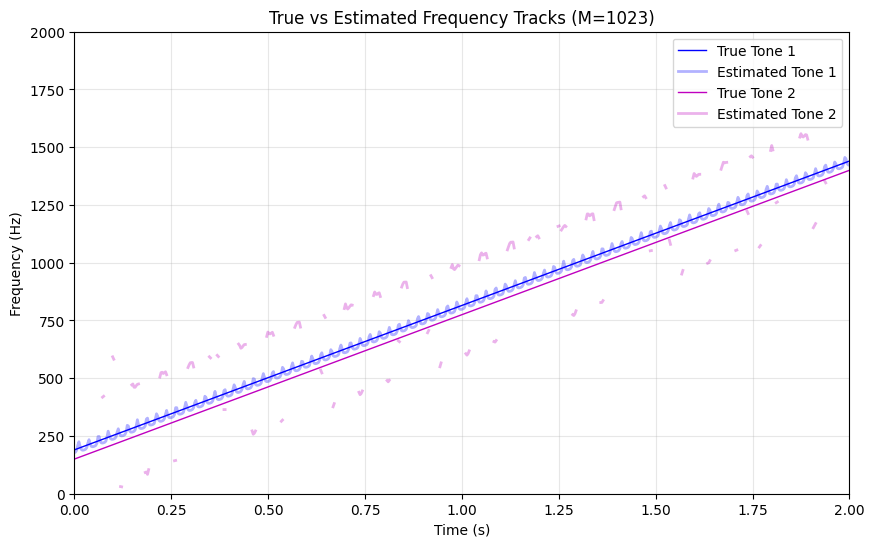

meanErr tone1: 13.669
meanErr tone2: 528.533


In [19]:
# E5 - 2.1: 
# First call function freq_tracker_error() with the test case values and plot the true versus the
# estimated frequency values, then change the window-size to obtain minimum possible error, and plot the new
# estimated frequency values. Explain the choice and result.

### Test case:
H = 128
window = 'blackman'
t = -80
input_file = '../sounds/chirp-150-190-linear.wav'
fs, x = UF.wavread(input_file)

M = 1023
tStamps = gen_time_stamps(x.size, M, fs, H)   # Generate the tStamps to return
fTrackTrue = gen_true_freq_tracks_chirp_150_190(tStamps)
### Your code here
meanErr, fTrackEst = freq_tracker_error(input_file, fTrackTrue, window, t, H, M)
plot_freq_traces(fTrackEst, fTrackTrue, fs, H, maxplotfreq=2000, title=f'(M={M})')

print(f"meanErr tone1: {meanErr[0]:.3f}")
print(f"meanErr tone2: {meanErr[1]:.3f}")

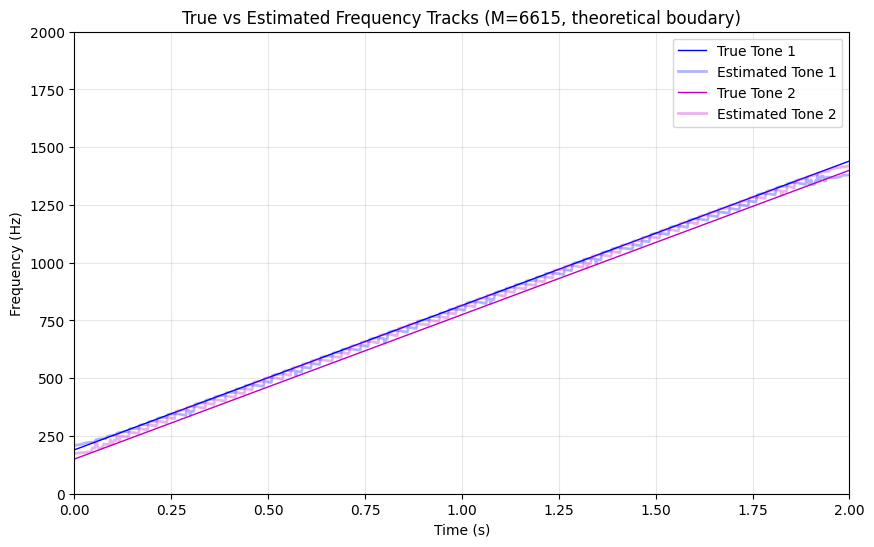

meanErr tone1: 10.209
meanErr tone2: 28.347


In [20]:
#Ideal M for desired freq resolution

#dictionary containing main-lobe side-width for different window types
window_bs = {           
    "blackman" : 6
}
fs = 44100
fres = 190-150

M = math.ceil(window_bs['blackman']*fs/ fres)#compute ideal M size based on desired f resolution
tStamps = gen_time_stamps(x.size, M, fs, H)   # Generate the tStamps
fTrackTrue = gen_true_freq_tracks_chirp_150_190(tStamps)
### Your code here
meanErr, fTrackEst = freq_tracker_error(input_file, fTrackTrue, window, t, H, M)
plot_freq_traces(fTrackEst, fTrackTrue, fs, H, maxplotfreq=2000, title=f'(M={M}, theoretical boudary)')

print(f"meanErr tone1: {meanErr[0]:.3f}")
print(f"meanErr tone2: {meanErr[1]:.3f}")

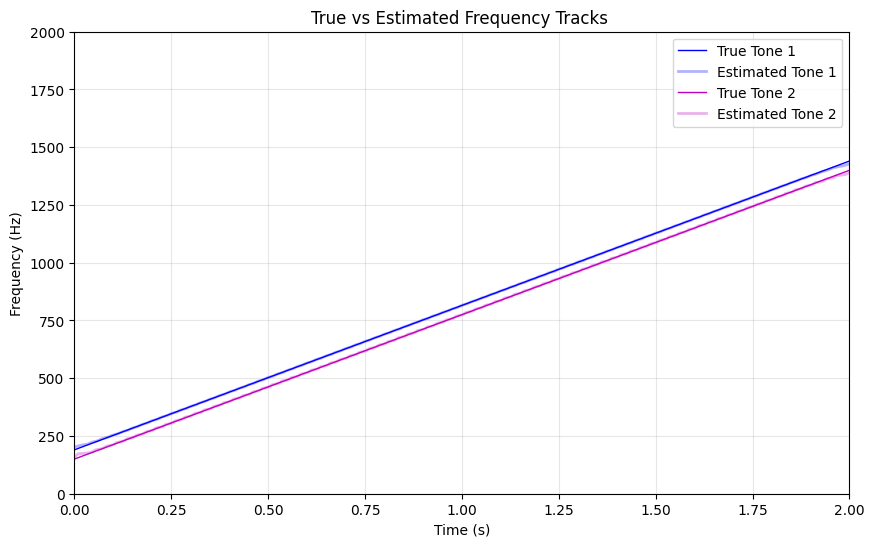

meanErr tone1: 0.737
meanErr tone2: 1.327


In [21]:
M=4500
tStamps = gen_time_stamps(x.size, M, fs, H)   # Generate the tStamps to return
fTrackTrue = gen_true_freq_tracks_chirp_150_190(tStamps)
### Your code here
meanErr, fTrackEst = freq_tracker_error(input_file, fTrackTrue, window, t, H, M)
plot_freq_traces(fTrackEst, fTrackTrue, fs, H, maxplotfreq=2000)
print(f"meanErr tone1: {meanErr[0]:.3f}")
print(f"meanErr tone2: {meanErr[1]:.3f}")

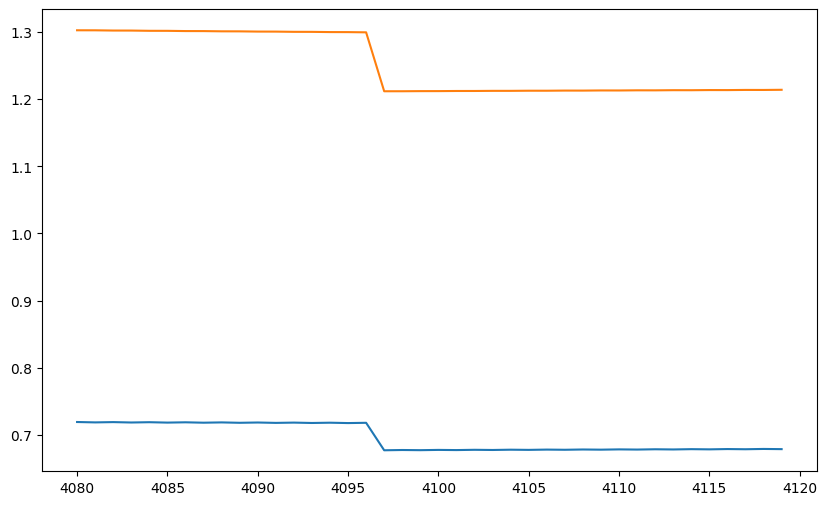

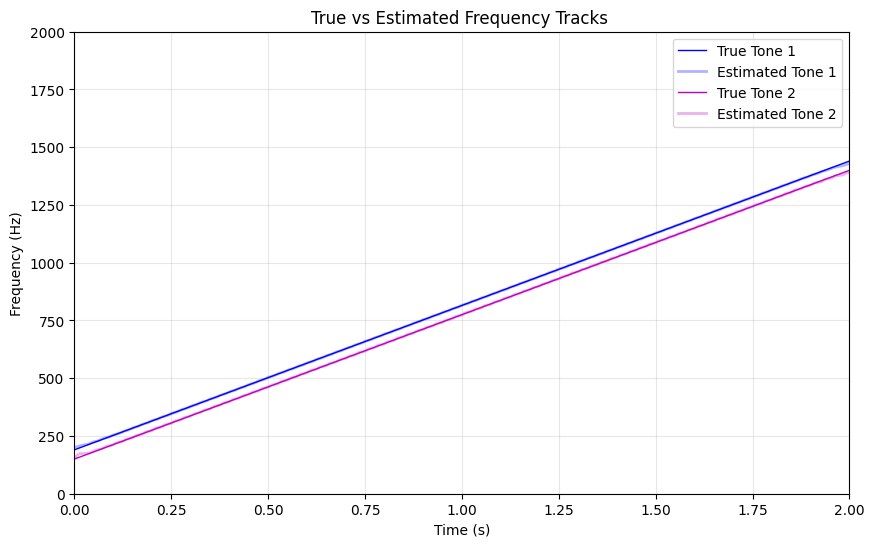

Best M: 4097
meanErr tone1: 0.677
meanErr tone2: 1.212


In [22]:
### Finding the minimum error by brute force
meanErrList =[]
bestM = -3
prev_maxMeanError = [500, 500]
for M in range(4080, 4120, 1):
    tStamps = gen_time_stamps(x.size, M, fs, H)   # Generate the tStamps to return
    fTrackTrue = gen_true_freq_tracks_chirp_150_190(tStamps)
    meanErr, fTrackEst = freq_tracker_error(input_file, fTrackTrue, window, t, H, M)
    meanErrList.append(meanErr)
    if max(meanErr)<max(prev_maxMeanError):
        prev_maxMeanError = meanErr
        bestM = M

plt.figure(figsize=(10, 6))
plt.plot(range(4080, 4120, 1),meanErrList)
#plt.axis([0, x.size / float(fs), 0, maxplotfreq])
plt.show()

M=bestM
tStamps = gen_time_stamps(x.size, M, fs, H)   # Generate the tStamps to return
fTrackTrue = gen_true_freq_tracks_chirp_150_190(tStamps)
### Your code here
meanErr, fTrackEst = freq_tracker_error(input_file, fTrackTrue, window, t, H, M)
plot_freq_traces(fTrackEst, fTrackTrue, fs, H, maxplotfreq=2000)
print(f"Best M: {bestM}")
print(f"meanErr tone1: {meanErr[0]:.3f}")
print(f"meanErr tone2: {meanErr[1]:.3f}")

**Question  E5 - 2.2:**

#### Explain the results of  2.1
------

Given two increasing chirps, we will have two contrains on the choice of the window size:
- M needs to be large enough to have a freq resolution that can differenciate the two sinusoinds ($\Delta f \geq 40Hz$)
- M needs to be short enough so it doesn't see such a big change in freq, which would confuse the computation averaging the presence of different frequencies (freq smearing)

> Test case:

In the Test case (M = 1023) we don't have enough frequency resolution to distinguish the two sinusoids: $F_{res}=\frac{F_s}{M}=\frac{44100}{1023}=43.1 > 40$, therefore we find spurious peaks in the spectrogram.


> Ideal frequency resolution case:

Now we know, we need a bigger $M$, but how big? Theoretically, in order to have enough frequency resolution to distinguish $\Delta f$ we need a window of size $M \geq B_s \frac{f_s}{\Delta f}$ where Bs is the main-lobe width of the window we are using. In our case $M \geq 6* \frac{44100}{40} = 6615$.

That's what we tried in our second attempt. Here we can see that at each timestamp, we are able to differenciate two different sines, however the estimated frequencies doesn't show the smooth increase that our original chirps do. That's because we are gainning frequency resolution on behalf of time resolution, which means that now our sinusoidal traker is not able to detect small increments in frequency. That's because we are looking at a long section of the signal at a time and the frequency increment for one chirp is big enough so that when averaging all over the window we are predicting a frequency too far away from the one that happens at a specific point.

> Find a compromise

Now we know upper and lower boundaries for the length of our window. In the third graph,  $M=4500$ shows a good compromise, since we have enough frequency resolution for detecting two independant sines but still enough time resolution to track it's ascending tone. Moreover, both mean errors for the estimaded versions of the frequency tracking are under 2Hz, which was our initial goal.

> Minimizing the error

The final cell includes a loop in order to try to minimize the estimation error. We can see that the ideal $M$ is $4097$, however, the meanError is very similar to the ones we got with $M=4500$ and the improvement in this case is not worth the increment on computational time that it takes to use brute force in order to optimize the parameter $M$.


## Part 3 -Tracking sinusoids of different amplitudes

In this part you should perform the best possible sinusoidal analysis of a signal with two sinusoidal components of different amplitudes by focusing on the type of window `window` and the magnitude threshold `t` of the function `sineModelAnal()`.

Use the input signal `sines-440-602-hRange.wav` which includes two sinusoidal components with a very large difference in their amplitude. It is a synthetically generated signal with frequency components 440Hz and 602Hz, `s = sin(2*pi*440*t) + 2e-3*sin(2*pi*602*t)`.

This part uses the same functions as Part 2.

Get familiar with the signal by listening to it and visualizing its spectrogram. Use `models_GUI.py` interface or sonic visualizer to see its spectrogram. Notice the difference in the amplitudes of its components.

To do this exercise complete the next cell. Run the function `freq_tracker_error()` giving a value for the window type `window` and the  magnitude threshold `t`. Use the given values for the rest of parameters.

For the `sineModelAnal()` function we use a window length `M = 2047` samples, an FFT size `N = 4096` samples, and a hop size `H = 128` samples. For sine tracking, we set `minSineDur = 0.02` seconds, `freqDevOffset = 10`Hz, and `freqDevSlope = 0.001` (its default value). Since we need only two frequency component estimates at every frame, we set `maxnSines = 2`.

Set the input parameters `window` and `t` such that the mean estimation error of each frequency components is less than 2Hz. There is a range of values of `M` and `t` for which this is true and all of those values will be considered correct answers. You can plot the estimated and true frequency tracks to visualize the accuracy of estimation. The output is the set of parameters you used: `window`, `t`, the time stamps, estimated and the true frequency tracks. Note that choosing the wrong window might lead to tracking of one of the sidelobes of the high amplitude sinusoid instead of the mainlobe of the low amplitude sinusoid.

For the window, choose one of `'boxcar'`, `'hanning'`, `'hamming'`, `'blackman'`, or `'blackmanharris'`. `t` should be specified in negative dB.

NOTE: Do not do just trial and error. Understand the problem and calculate and `M` that should work. Then test it and refine the answer.

__Test case:__ Choosing `window = 'hanning'`, `t = -80.0`, the mean estimation error is `[0.19603701  29.51140815]` Hz.


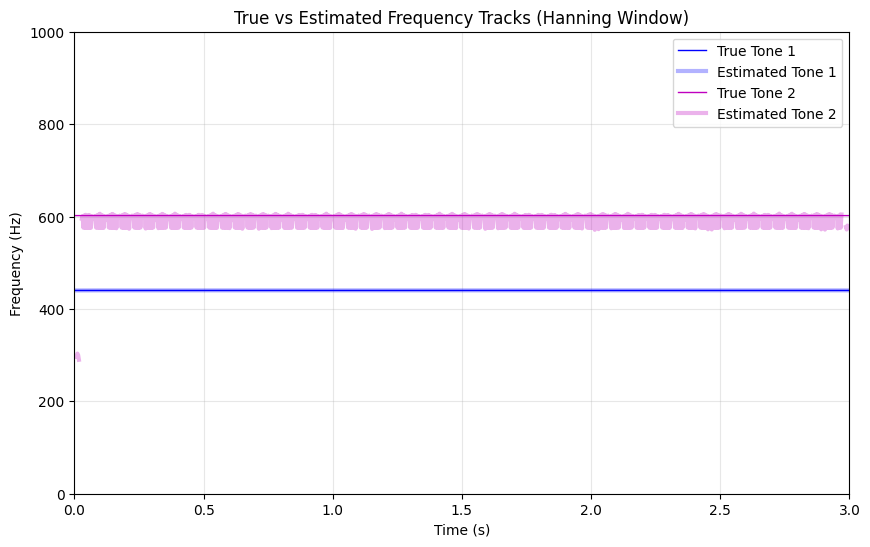

meanErr tone1: 0.196
meanErr tone2: 29.511


In [29]:
# E5 - 3.1: 
# First call freq_tracker_error() with the values for the test case and plot the true versus the
# estimated frequency values. Then choose the window and threshold to obtain minimum possible error, and plot
# the new estimated frequency values. Explain the result.

M = 2047                                             # Window size
N = 4096                                             # FFT Size
H = 128                                              # Hop size in samples
input_file = '../sounds/sines-440-602-hRange.wav'
fs, x = UF.wavread(input_file)
tStamps = gen_time_stamps(x.size, M, fs, H)   # Generate the tStamps to return
fTrackTrue = gen_true_freq_tracks_440_602 (tStamps)


### Your code here
window = 'hann'
t = -80
meanErr, fTrackEst = freq_tracker_error(input_file, fTrackTrue, window, t, H, M)
plot_freq_traces(fTrackEst, fTrackTrue, fs, H, maxplotfreq=1000, line_width=[3, 1], title='(Hanning Window)')

print(f"meanErr tone1: {meanErr[0]:.3f}")
print(f"meanErr tone2: {meanErr[1]:.3f}")


In [30]:
#redefine the tacker to match the stated parameters

def freq_tracker_error(input_file, fTrackTrue, window, t, H, M):
    """Estimate sinusoidal values of a sound

    Args:
        input_file (str): wav file including the path
        fTrackTrue (np.array): array of true frequency values, one row per time frame, one column per component
        window (str): window type used for analysis
        t (float): peak picking threshold (negative dB)
        H (int): hop size in samples
        M (int): window size in samples

   Result:
           float: mean estimation error
           np.array: estimated frequency values, one row per time frame, one column per component

    """

    N = int(pow(2, np.ceil(np.log2(M))))        # FFT Size, power of 2 larger than M
    maxnSines = 2                               # Maximum number of sinusoids at any time frame
    minSineDur = 0.02                           # minimum duration set to zero to not do tracking
    freqDevOffset = 10                          # minimum frequency deviation at 0Hz
    freqDevSlope = 0.001                        # slope increase of minimum frequency deviation

    fs, x = UF.wavread(input_file)              # read input sound
    w = get_window(window, M)                   # Compute analysis window
    # analyze the sound with the sinusoidal model
    fTrackEst, mTrackEst, pTrackEst = SM.sineModelAnal(x, fs, w, N, H, t, maxnSines, minSineDur, freqDevOffset, freqDevSlope)
    tailF = 20
    # Compute mean estimation error. 20 frames at the beginning and end not used to compute error
    meanErr = np.mean(np.abs(fTrackTrue[tailF:-tailF,:] - fTrackEst[tailF:-tailF,:]),axis=0)

    return (meanErr, fTrackEst)

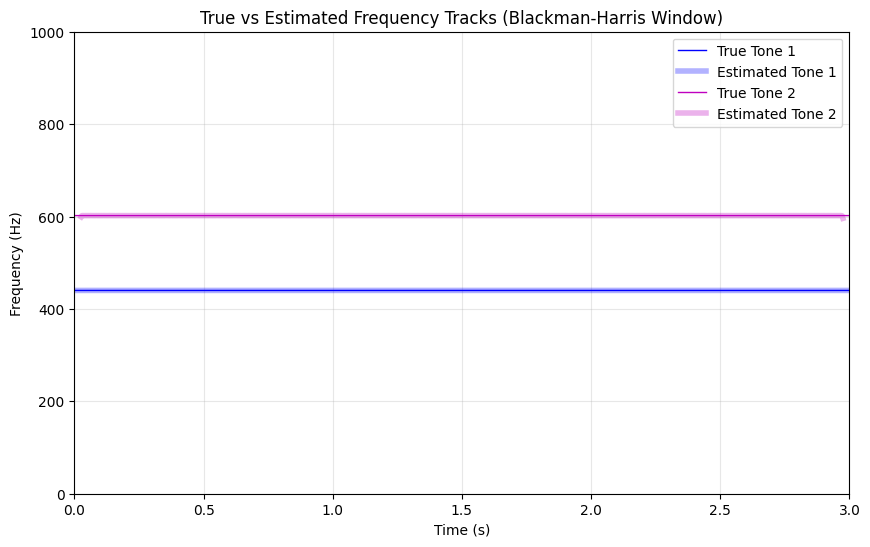

meanErr tone1: 0.037
meanErr tone2: 0.060


In [34]:
### Your code here
window = 'blackmanharris'
t = -92
M = 2000                             
meanErr, fTrackEst = freq_tracker_error(input_file, fTrackTrue, window, t, H, M)
plot_freq_traces(fTrackEst, fTrackTrue, fs, H, maxplotfreq=1000, line_width=[4, 1], title='(Blackman-Harris Window)')

print(f"meanErr tone1: {meanErr[0]:.3f}")
print(f"meanErr tone2: {meanErr[1]:.3f}")

**Question  E5 - 3.2:**
#### Explain the results of 3.1

In this part we are paying special attention to how the side lobes of a sinc function can mask other frequency components. For this purpose, we have analyzed a signal containing two sinusoids with very different amplitudes. Note that different window types exhibit sidelobes with varying levels. Regarding our goal: to be able to estimate the two frequencies with an error of less than 2 Hz, we need windows with high attenuation in the sidelobes, such as Blackmann (-58 dB) or Blackmann-Harris (-92 dB).

> Test case:

As we can see, the high amplitude sinusoid (440Hz) is very well tracked, however, the low amplitude one (602Hz) is not well detected. That's becasue the Hanning window has a side-lobe level of -31.5 dB, which is not enough to avoid the sidelobes of the 440Hz sinusoid masking the 602Hz spectral peak. 

> Tuned parameters:

In order to avoid what happened in the test case, I chose a Blackman-Harris window and set the theshold value for the sinusoidal traking at -92dB, which is the Blackman-Harris window side-lobe level. For the window length, I used the lower boundary presented in part 2 to find a first appropiate value: $M \geq B_s \frac{f_s}{\Delta f} =   8 * \frac{44100}{602-440} \approx  2178$. After seeing that using $M=2178$ lead to a bit of impresicion at the edges, I tryed with a low value ($M=2000$) which reduces a bit the anomalies at the beggining and at the end of the signal.

## Part 4 - Sinusoidal modeling of a multicomponent signal

In this part you will perform a sinusoidal analysis of a complex synthetic signal, using `sineModelAnal()` exploring the different parameters of the model. Use the sound `multiSines.wav` and explain the difficulties encoutered and solutions found.

This is an open question without a single specific answer. We will use the sound `multiSines.wav`, which is a synthetic audio signal with sharp attacks, close frequency components with a wide range of amplitudes, and time varying chirps with frequency tracks that cross over. All these characteristics make this signal difficult to analyze with `sineModelAnal()`. Get familiar with the signal by listening to it and visualizing its spectrogram. Use `models_GUI.py` interface or Sonic Visualizer to see its spectrogram.

We have written a basic code for sinusoidal analysis, you are free to modify it. You should be able to generate a sound that is perceptually undistinguishable from the input sound.


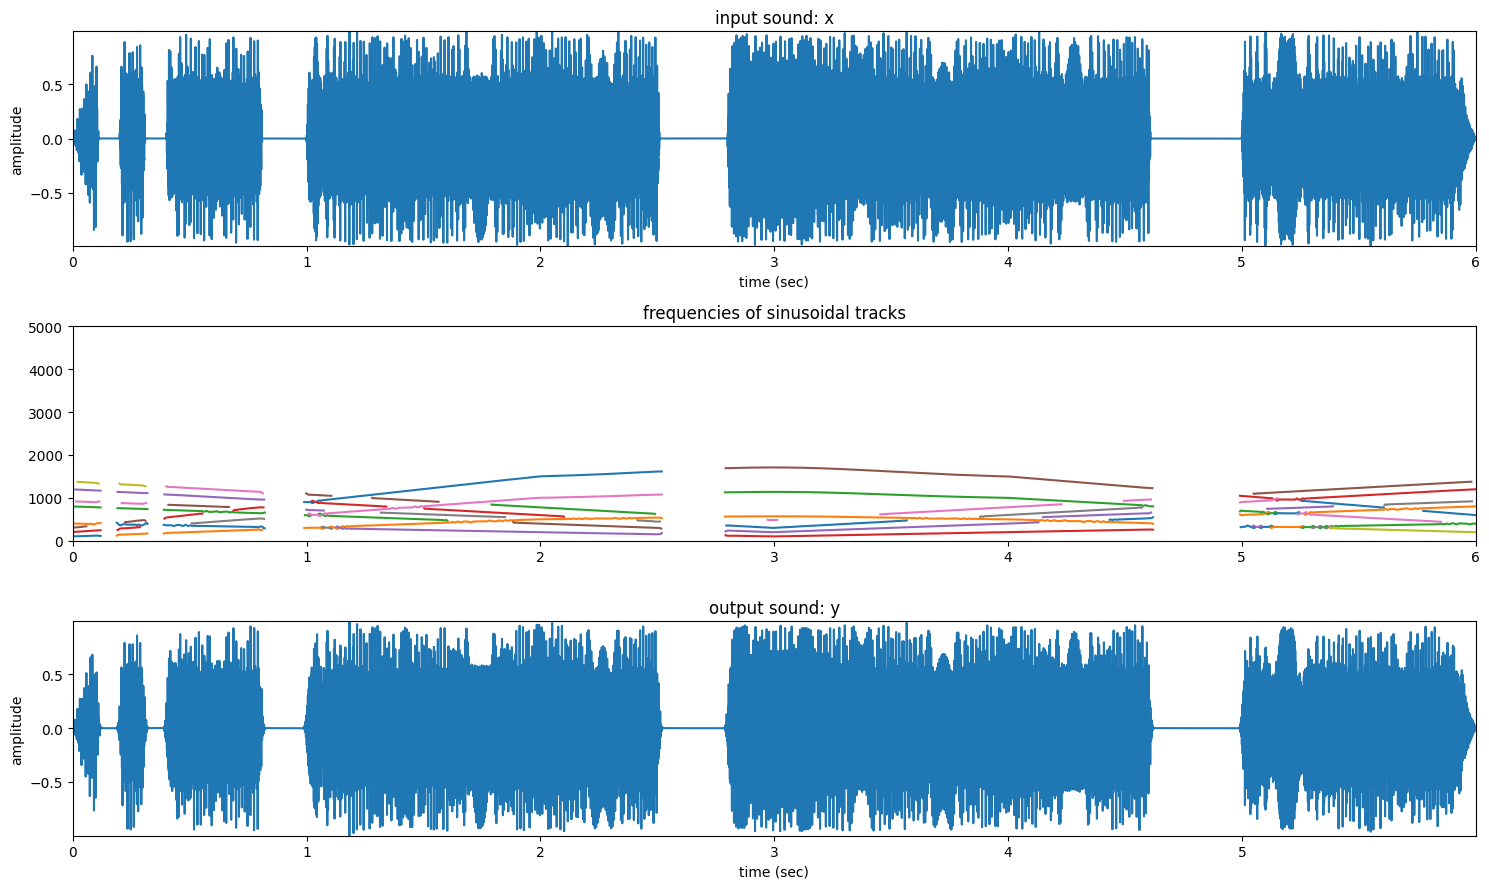

In [43]:
# E5 - 4.1: 
# Set the analysis parameters of sineModelAnal() to perform the best analysis of multiSines.wav

import IPython.display as ipd

input_file = '../sounds/multiSines.wav'

### set the analysis parameters

window = 'blackman'#harris'
M = 1900
N = 2048
t = -58
minSineDur = 0.02
maxnSines = 15
freqDevOffset = 30
freqDevSlope = 0.001


# no need to modify the code after here
Ns = 512                                      # size of fft used in synthesis
H = 128                                       # hop size (has to be 1/4 of Ns)

fs, x = UF.wavread(input_file)                # read input sound
w = get_window(window, M)                     # compute analysis window

# analyze the sound with the sinusoidal model
tfreq, tmag, tphase = SM.sineModelAnal(x, fs, w, N, H, t, maxnSines, minSineDur, freqDevOffset, freqDevSlope)

# synthesize the output sound from the sinusoidal representation
y = SM.sineModelSynth(tfreq, tmag, tphase, Ns, H, fs)

# create figure to show plots
plt.figure(figsize=(15, 9))

# frequency range to plot
maxplotfreq = 5000.0

# plot the input sound
plt.subplot(3,1,1)
plt.plot(np.arange(x.size)/float(fs), x)
plt.axis([0, x.size/float(fs), min(x), max(x)])
plt.ylabel('amplitude')
plt.xlabel('time (sec)')
plt.title('input sound: x')

# plot the sinusoidal frequencies
plt.subplot(3,1,2)
if (tfreq.shape[1] > 0):
    numFrames = tfreq.shape[0]
    frmTime = H*np.arange(numFrames)/float(fs)
    tfreq[tfreq<=0] = np.nan
    plt.plot(frmTime, tfreq)
    plt.axis([0, x.size/float(fs), 0, maxplotfreq])
    plt.title('frequencies of sinusoidal tracks')

# plot the output sound
plt.subplot(3,1,3)
plt.plot(np.arange(y.size)/float(fs), y)
plt.axis([0, y.size/float(fs), min(y), max(y)])
plt.ylabel('amplitude')
plt.xlabel('time (sec)')
plt.title('output sound: y')
plt.tight_layout()
ipd.display(ipd.Audio(data=x, rate=fs))
ipd.display(ipd.Audio(data=y, rate=fs))

**Question  E5 - 4.2:**


In order to be able to reconstrunt an indistinguishable signal, it's crutial to choose the proper parameters. On the first place, I chose the $Blackman$ window becasue it offers a good trade-off between main-lobe width and side-lobe attenuation. It has a low side-lobe level (needed to avoid masking of low amplitude sinusoids with big amplitude sinusoids side-lobes), but still allows for enough time resolution to be able to track the frequency change chirps and enough frequency resolution to be able to distinguish them, even when they are close in frequency. The choice of this window also implies the threshold $t$ choice, which I set to -58dB since it's the Blackman window side-lobe level.

The $maxnSines$ variable limits the number of simultaneous sinusoidals to track and keep synthesis computationally efficient. I set it to 15 since there are not more than 15 simultaneous sinusoids. Actually there are less than 15, however I wanted to leave room for some mistakes (ideally not perceptibles) in order so be able to reconstruct a more complete signal.

$M=1900$ wa chosen to be relatively long analysis window which gives high frequency resolution, which is crucial for resolving partials that are very close in frequency, but at the same time, it remains short enough to follow the time-varying components (chirps and attacks). Still, the algorithm struggles a bit to detect the attacks properly. $N = 2028$ is chosen as a power of two larger than M.

Finally, $minSineDur = 0.02$ ensures that only stable enough partials lasting at least 20 ms are considered, avoiding spurious short-lived detections. $freqDevOffset = 30$ and $freqDevSlope = 0.001$ control how much frequency deviation is allowed when connecting peaks into tracks. The chosen moderate values help maintainning continuity in frequency tracks even when crossings occur.